# Proyek Analisis Data: Bike Sharing Dataset


## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Berapa besar persentase peningkatan rata-rata jumlah penyewaan sepeda (cnt) pada jam sibuk/rush hour pagi (07.00 - 09.00) dan sore (16.00 - 18.00) dibandingkan jam-jam lainnya pada hari kerja (workingday = 1) sepanjang tahun 2012?
- **Pertanyaan 2:** Kondisi cuaca mana (weathersit: Level 1 Cerah, Level 2 Berawan, atau Level 3/4 Badai) yang menghasilkan rata-rata jumlah penyewaan sepeda (cnt) harian tertinggi sepanjang tahun 2012?
- **Pertanyaan 3:** Berapa selisih rata-rata jumlah penyewaan sepeda (cnt) antara hari libur (holiday) dan hari biasa pada rentang jam 06.00–21.00 sepanjang tahun 2011 dan 2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

## Data Wrangling

### Gathering Data

#### Load df

In [2]:
day_df = pd.read_csv("https://drive.google.com/uc?export=download&id=12RMFPxG544eJzY_lANj9TmjyVI2HR1l2")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
hour_df = pd.read_csv("https://drive.google.com/uc?export=download&id=1o3A23yog9OOAdixUg6C9YSnG2Uuj1_MH")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


#### Membaca Readme.txt

In [4]:
readme = requests.get("https://drive.google.com/uc?export=download&id=1LEsXSZtdFyvbit9jjzoOO4eRy2Xaf19j")
print(readme.text)

Bike Sharing Dataset

Hadi Fanaee-T

Laboratory of Artificial Intelligence and Decision Support (LIAAD), University of Porto
INESC Porto, Campus da FEUP
Rua Dr. Roberto Frias, 378
4200 - 465 Porto, Portugal


Background 

Bike sharing systems are new generation of traditional bike rentals where whole process from membership, rental and return 
back has become automatic. Through these systems, user is able to easily rent a bike from a particular position and return 
back at another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of 
over 500 thousands bicycles. Today, there exists great interest in these systems due to their important role in traffic, 
environmental and health issues. 

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by
these systems make them attractive for the research. Opposed to other transport services such as bus or subway, the duration
of tra

#### Kesimpulan

**Insight:**   
Dataset berisi day.csv, hour.csv, dan readme.txt yang menjelaskan tentang :  

Data pada kolom dengan categorical variables yang dikodekan menjadi angka
- season   
(1 = Spring, 2 = Summer, 3 = Fall, 4 = Winter)
- yr  
(0 = 2011, 1 = 2012)
- mnth  
(1 = Januari, 2 = Februari, ... , 12 = Desember)
- hr  
(0 = Jam 00.00, 1 = Jam 01.00, ... , 23 = Jam 23.00)
- holiday  
(0 = bukan holiday, 1 = holiday)
- weekday  
(0 = Minggu, 1 = Senin, ... , 6 = Sabtu)
- workingday  
(0 = Bukan hari kerja, 1 = Hari Kerja)
- weathersit  
(Diberi Kesimpulan menjadi beberapa kategori, yaitu 1 = Kategori Cerah, 2 = Kategori Berawan, 3 = Kategori Badai Ringan, 4 = Kategori Badai Berat

Dan ada juga beberapa data yang sudah dinormalisasi
- temp (dibagi 41)
- atemp (dibagi 50)
- hum (dibagi 100)
- windspeed (dibagi 67)

### Assessing Data

#### Menilai Dataset

##### Dataset Day

In [5]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**PROBLEM:** Tipe kolom 'dteday' seharusnya `datetime`  


In [6]:
day_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

**Insight:** Tidak ada missing value

In [7]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:** Tidak ada duplicated data

In [8]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:** Tidak ada inaccurate value

##### Dataset Hour

In [9]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**PROBLEM:** Tipe kolom 'dteday' seharusnya `datetime`  


In [10]:
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

**Insight:** Tidak ada missing value

In [11]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:** Tidak ada duplicated data

In [12]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:** Tidak ada inaccurate value

#### Kesimpulan

**Insight:**
- Tipe data Kolom 'dteday' pada day_df dan hour_df seharusnya `datetime`
- Tidak ada missing value, duplicated data, dan inaccurate value pada day_df dan hour_df

**Steps to Take:**
- Pada Cleaning Data, mengganti Tipe data Kolom 'dteday' menjadi `datetime`

### Cleaning Data

#### Perbaikan Tipe Data 'dteday'

##### Dataset Day

In [13]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [14]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:** Tipedata 'dteday' pada day_df telah berhasil diubah menjadi `datetime`

##### Dataset Hour

In [15]:
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [16]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:** Tipedata 'dteday' pada hour_df telah berhasil diubah menjadi `datetime`

#### Cek Kembali 'cnt' apakah sudah benar

##### Dataset Day

In [17]:
day_df['cnt_check'] = day_df['casual'] + day_df['registered']
selisih_day = day_df[day_df['cnt'] != day_df['cnt_check']]

print(f"Jumlah baris yang tidak cocok: {len(selisih_day)}")

Jumlah baris yang tidak cocok: 0


In [18]:
day_df = day_df.drop(columns=['cnt_check'])

**Insight:** Tidak ada hasil 'cnt' pada day_df yang tidak sesuai dengan penjumlahan antara 'casual' dan 'registered'

##### Dataset Hour

In [19]:
hour_df['cnt_check'] = hour_df['casual'] + hour_df['registered']
selisih_hour = hour_df[hour_df['cnt'] != hour_df['cnt_check']]

print(f"Jumlah baris yang tidak cocok: {len(selisih_hour)}")

Jumlah baris yang tidak cocok: 0


In [20]:
hour_df = hour_df.drop(columns=['cnt_check'])

**Insight:** Tidak ada hasil 'cnt' pada hour_df yang tidak sesuai dengan penjumlahan antara 'casual' dan 'registered'

## Exploratory Data Analysis (EDA)

### EDA Untuk Pertanyaan 1

#### Membuat DF Khusus bernama 'pertanyaan1_df'

In [21]:
pertanyaan1_df = hour_df[(hour_df['yr'] == 1) & (hour_df['workingday'] == 1)].copy()

pertanyaan1_df ini dibuat dengan copy dari hour_df dengan ketentuan yr sebesar 1 dan workingday sebesar 1

#### Membuat kolom baru 'rushhour'

In [22]:
pertanyaan1_df['rushhour'] = pertanyaan1_df['hr'].isin([7, 8, 9, 16, 17, 18]).astype(int)

Menambahkan kolom baru bernama rushhour dengan aturan pengisian data :  

1 = Jam Sibuk ([07.00 - 09.00] atau [16.00 - 18.00])  
0 = Jam Lainnya

In [23]:
pertanyaan1_df.head(20)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,rushhour
8692,8693,2012-01-03,1,1,1,0,0,2,1,1,0.20,0.1970,0.51,0.2537,0,13,13,0
8693,8694,2012-01-03,1,1,1,1,0,2,1,1,0.18,0.1818,0.55,0.2239,1,5,6,0
8694,8695,2012-01-03,1,1,1,2,0,2,1,1,0.18,0.1667,0.51,0.2537,0,3,3,0
8695,8696,2012-01-03,1,1,1,3,0,2,1,1,0.16,0.1364,0.55,0.2836,0,2,2,0
8696,8697,2012-01-03,1,1,1,4,0,2,1,1,0.16,0.1515,0.55,0.2537,0,5,5,0
8697,8698,2012-01-03,1,1,1,5,0,2,1,1,0.14,0.1364,0.54,0.1940,0,12,12,0
8698,8699,2012-01-03,1,1,1,6,0,2,1,1,0.14,0.1212,0.59,0.2836,4,81,85,0
8699,8700,2012-01-03,1,1,1,7,0,2,1,1,0.14,0.1212,0.59,0.2537,2,168,170,1
8700,8701,2012-01-03,1,1,1,8,0,2,1,1,0.16,0.1364,0.55,0.2836,5,349,354,1
8701,8702,2012-01-03,1,1,1,9,0,2,1,1,0.16,0.1364,0.50,0.2836,8,145,153,1


#### Menghitung Mean dari 'cnt' berdasarkan value 'rushhour'




In [24]:
mean_cnt_rushhour = pertanyaan1_df.groupby(by='rushhour').agg({
    "cnt" : "mean"
  }).reset_index()


In [25]:
mean_cnt_rushhour

,rushhour,cnt
0,0,159.263500
1,1,486.487592


#### Menghitung Kenaikan Peningkatan 'cnt'

In [26]:
mean_jam_sibuk = mean_cnt_rushhour.loc[mean_cnt_rushhour['rushhour'] == 1, 'cnt'].values[0]

In [27]:
mean_jam_lainnya = mean_cnt_rushhour.loc[mean_cnt_rushhour['rushhour'] == 0, 'cnt'].values[0]

In [28]:
total_peningkatan_rushhour = mean_jam_sibuk - mean_jam_lainnya
persentase_peningkatan_rushhour = (total_peningkatan_rushhour / mean_jam_lainnya) * 100

print("Total Peningkatan Rata-Rata Penyewaan pada Jam Sibuk sebesar", total_peningkatan_rushhour, "dan Persentase Peningkatan Rata-Rata Penyewaan pada Jam Sibuk Sebesar", persentase_peningkatan_rushhour, "%")

Total Peningkatan Rata-Rata Penyewaan pada Jam Sibuk sebesar 327.22409233201887 dan Persentase Peningkatan Rata-Rata Penyewaan pada Jam Sibuk Sebesar 205.46081968699755 %


**Insight:** Rata-rata penyewaan sepeda tahun 2012 pada jam Rush Hour (07.00 - 09.00 dan 16.00 - 18.00) lebih tinggi dibandingkan dengan jam lainnya.



### EDA Untuk Pertanyaan 2

#### Membuat DF Khusus bernama 'pertanyaan2'

In [29]:
pertanyaan2_df = hour_df[hour_df['yr'] == 1].copy()

pertanyaan2_df ini dibuat dengan copy dari hour_df dengan ketentuan yr sebesar 1

#### Menghitung Mean dari 'cnt' berdasarkan value 'weathersit'




In [30]:
mean_cnt_weathersit = pertanyaan2_df.groupby(by='weathersit').agg({
    "cnt" : "mean"
}).reset_index()

In [31]:
mean_cnt_weathersit

,weathersit,cnt
0,1,253.661581
1,2,212.997850
2,3,142.376176
3,4,93.500000


**Insight:** Rata-rata penyewaan sepeda tahun 2012 pada cuaca dengan kategori cerah (Clear, Few clouds, Partly cloudy, Partly cloudy) lebih banyak jika dibandingkan dengan cuaca dengan kategori yang lain.




### EDA Untuk Pertanyaan 3

#### Membuat DF Khusus bernama 'pertanyaan3_df'

In [32]:
pertanyaan3_df = hour_df[(hour_df['hr'] >= 6) & (hour_df['hr'] <= 21)].copy()

In [33]:
pertanyaan3_df.head(50)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14
10,11,2011-01-01,1,0,1,10,0,6,0,1,0.38,0.3939,0.76,0.2537,12,24,36
11,12,2011-01-01,1,0,1,11,0,6,0,1,0.36,0.3333,0.81,0.2836,26,30,56
12,13,2011-01-01,1,0,1,12,0,6,0,1,0.42,0.4242,0.77,0.2836,29,55,84
13,14,2011-01-01,1,0,1,13,0,6,0,2,0.46,0.4545,0.72,0.2985,47,47,94
14,15,2011-01-01,1,0,1,14,0,6,0,2,0.46,0.4545,0.72,0.2836,35,71,106
15,16,2011-01-01,1,0,1,15,0,6,0,2,0.44,0.4394,0.77,0.2985,40,70,110


In [34]:
pertanyaan3_df[pertanyaan3_df['holiday'] == 1].head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
378,379,2011-01-17,1,0,1,6,1,1,0,2,0.18,0.1818,0.43,0.1940,0,5,5
379,380,2011-01-17,1,0,1,7,1,1,0,2,0.16,0.1818,0.50,0.1343,4,9,13
380,381,2011-01-17,1,0,1,8,1,1,0,2,0.16,0.1515,0.47,0.2239,3,30,33
381,382,2011-01-17,1,0,1,9,1,1,0,2,0.16,0.1515,0.47,0.2239,8,39,47
382,383,2011-01-17,1,0,1,10,1,1,0,2,0.16,0.1515,0.50,0.2537,7,50,57


#### Menghitung Mean dari 'cnt' berdasarkan value 'holiday'

In [35]:
mean_cnt_holiday = pertanyaan3_df.groupby(by='holiday').agg({
    "cnt" : "mean"
}).reset_index()

In [36]:
mean_cnt_holiday

,holiday,cnt
0,0,261.231721
1,1,213.764881


In [37]:
mean_hari_biasa = mean_cnt_holiday.loc[mean_cnt_holiday['holiday'] == 0, 'cnt'].values[0]
mean_hari_liburan = mean_cnt_holiday.loc[mean_cnt_holiday['holiday'] == 1, 'cnt'].values[0]

In [38]:
total_penurunan_holiday = mean_hari_biasa - mean_hari_liburan
persentase_penurunan_holiday = (total_penurunan_holiday / mean_hari_biasa) * 100

print("Total Penurunan Rata-Rata Penyewaan pada Hari Liburan sebesar", total_penurunan_holiday, "dan Persentase Penurunan Rata-Rata Penyewaan pada Hari Liburan Sebesar", persentase_penurunan_holiday, "%")

Total Penurunan Rata-Rata Penyewaan pada Hari Liburan sebesar 47.46684038083447 dan Persentase Penurunan Rata-Rata Penyewaan pada Hari Liburan Sebesar 18.170396818037233 %


Insight: Rata-rata penyewaan sepeda tahun 2011 sampai 2012 pada hari liburan lebih rendah dibandingkan dengan hari biasa.



## Visualization & Explanatory Analysis

### Visualisasi untuk Pertanyaan 1

C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\466966900.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\466966900.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Jam Lainnya', 'Jam Sibuk'])


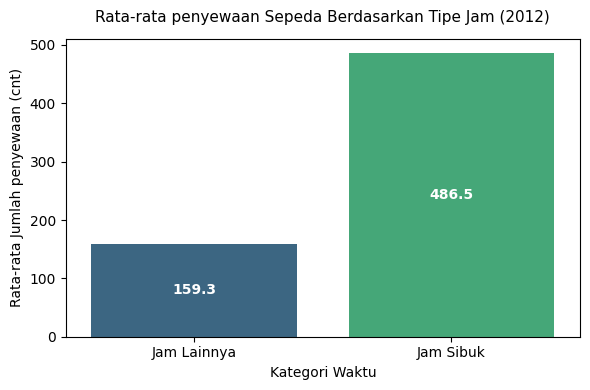

In [39]:
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=mean_cnt_rushhour,
    x='rushhour',
    y='cnt',
    palette='viridis'
)

ax.set_xticklabels(['Jam Lainnya', 'Jam Sibuk'])

plt.title('Rata-rata penyewaan Sepeda Berdasarkan Tipe Jam (2012)', fontsize=11, pad=12)
plt.xlabel('Kategori Waktu', fontsize=10)
plt.ylabel('Rata-rata Jumlah penyewaan (cnt)', fontsize=10)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white',
                xytext=(0, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

### Visualisasi Untuk Pertanyaan 2

C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\708900113.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\708900113.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Cerah', 'Berawan', 'Badai Ringan', 'Badai Berat'])


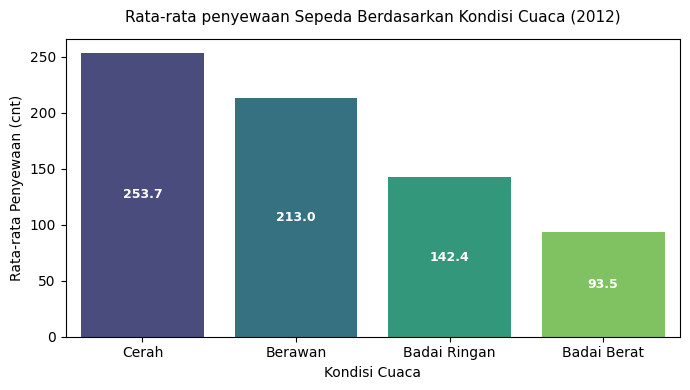

In [40]:
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=mean_cnt_weathersit,
    x='weathersit',
    y='cnt',
    palette='viridis'
)

ax.set_xticklabels(['Cerah', 'Berawan', 'Badai Ringan', 'Badai Berat'])

plt.title('Rata-rata penyewaan Sepeda Berdasarkan Kondisi Cuaca (2012)', fontsize=11, pad=12)
plt.xlabel('Kondisi Cuaca', fontsize=10)
plt.ylabel('Rata-rata Penyewaan (cnt)', fontsize=10)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center',
                va='center',
                color='white',
                fontweight='bold',
                fontsize=9)

plt.tight_layout()
plt.show()

### Visualisasi Untuk Pertanyaan 3

C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\2618274877.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\2618274877.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Hari Biasa', 'Hari Liburan'])


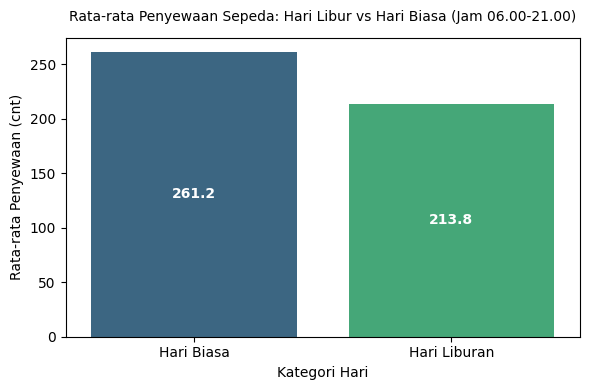

In [41]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=mean_cnt_holiday,
    x='holiday',
    y='cnt',
    palette='viridis'
)

ax.set_xticklabels(['Hari Biasa', 'Hari Liburan'])

plt.title('Rata-rata Penyewaan Sepeda: Hari Libur vs Hari Biasa (Jam 06.00-21.00)', fontsize=10, pad=12)
plt.xlabel('Kategori Hari', fontsize=10)
plt.ylabel('Rata-rata Penyewaan (cnt)', fontsize=10)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white',
                xytext=(0, 0), textcoords='offset points')

plt.tight_layout()
plt.show()


## Analisis Lanjutan (Opsional)

### Matriks Korelasi

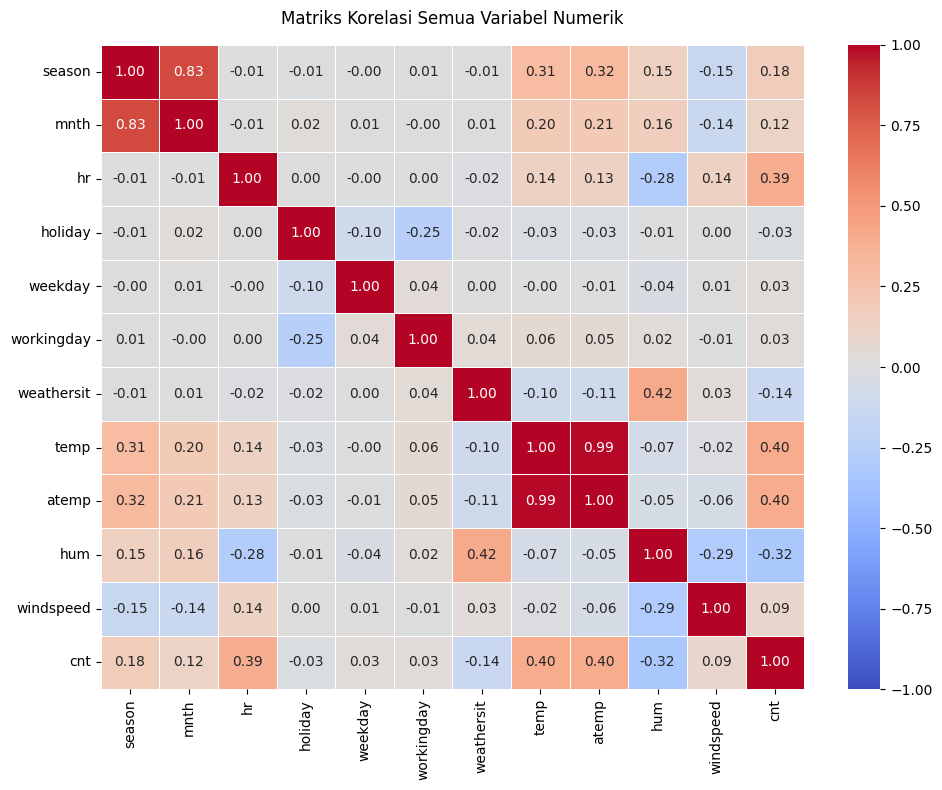

In [42]:
plt.figure(figsize=(10, 8))

matrix_corr = matrix_cor = hour_df.drop(columns=['instant','casual','registered', 'yr']).corr(numeric_only=True)

sns.heatmap(matrix_corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.title('Matriks Korelasi Semua Variabel Numerik', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

Alasan kenapa ada beberapa kolom di drop :
* instant -> Hanya penomoran index dari dataset
* casual dan registered -> Perbedaan tipe penyewaan sepeda saja
* yr -> Hanya memiliki dua tahun (2011 dan 2012), jadi datasetnya kurang representasif untuk analisis tahunan

**Insight:** Berdasarkan Matriks Korelasi, cnt berkorelasi positif paling kuat dengan suhu (temp), suhu feels-like (atemp), dan jam (hr)

### Rata-rata penyewaan sepeda berdasarkan hari

In [43]:
mean_cnt_day = day_df.groupby(by='weekday').agg({
    "cnt":"mean"
})

In [44]:
mean_cnt_day

,cnt
weekday,
0,4228.828571
1,4338.123810
2,4510.663462
3,4548.538462
4,4667.259615
5,4690.288462
6,4550.542857


In [45]:
q_map_day = {
    'q25': 0.25,
    'q50': 0.50,
    'q75': 0.75,
    'q90': 0.90
}

for col_name, q_val in q_map_day.items():
    threshold = mean_cnt_day['cnt'].quantile(q_val)
    mean_cnt_day[col_name] = (mean_cnt_day['cnt'] > threshold).astype(int)

mean_cnt_day



,cnt,q25,q50,q75,q90
weekday,,,,,
0,4228.828571,0,0,0,0
1,4338.123810,0,0,0,0
2,4510.663462,1,0,0,0
3,4548.538462,1,0,0,0
4,4667.259615,1,1,1,0
5,4690.288462,1,1,1,1
6,4550.542857,1,1,0,0


In [46]:
conditions = [
    mean_cnt_day['q90'] == 1,
    mean_cnt_day['q75'] == 1,
    mean_cnt_day['q50'] == 1,
    mean_cnt_day['q25'] == 1
]

choices = [
    'Kuantil >90%',
    'Kuantil 75-90%',
    'Kuantil 50-75%',
    'Kuantil 25-50%'
]

mean_cnt_day['kategori'] = np.select(condlist=conditions, choicelist=choices, default='Kuantil <25%')

print(mean_cnt_day[['cnt', 'kategori']])

                 cnt        kategori
weekday                             
0        4228.828571    Kuantil <25%
1        4338.123810    Kuantil <25%
2        4510.663462  Kuantil 25-50%
3        4548.538462  Kuantil 25-50%
4        4667.259615  Kuantil 75-90%
5        4690.288462    Kuantil >90%
6        4550.542857  Kuantil 50-75%


C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\2691998403.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\2691998403.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Minggu', 'Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu'])


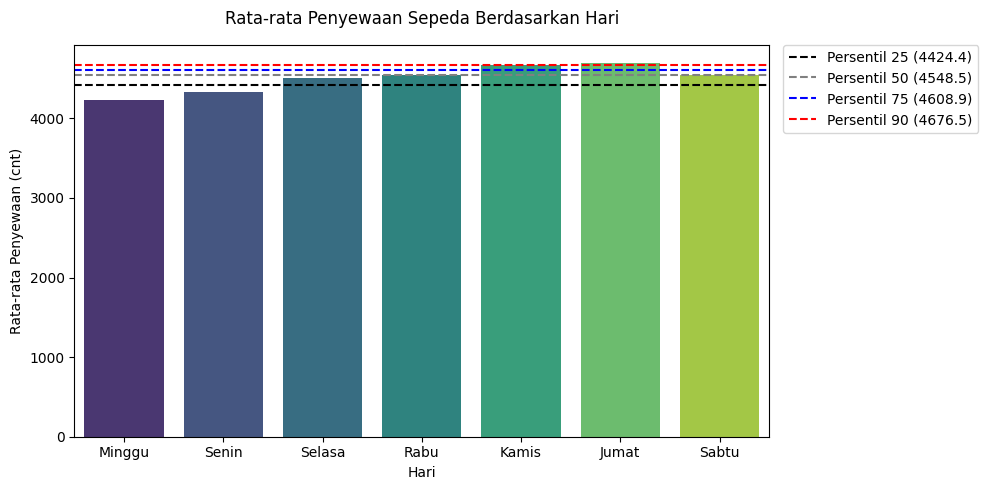

In [47]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=mean_cnt_day,
    x='weekday',
    y='cnt',
    palette='viridis'
)

colors = {
    'q25': 'black',
    'q50': 'gray',
    'q75': 'blue',
    'q90': 'red'
}

for col_name, q_val in q_map_day.items():
    threshold_val = mean_cnt_day['cnt'].quantile(q_val)
    
    plt.axhline(
        y=threshold_val,
        color=colors[col_name],
        linestyle='--',
        linewidth=1.5,
        label=f'Persentil {int(q_val*100)} ({threshold_val:.1f})'
    )

ax.set_xticklabels(['Minggu', 'Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu'])
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Hari', fontsize=12, pad=15)
plt.xlabel('Hari', fontsize=10)
plt.ylabel('Rata-rata Penyewaan (cnt)', fontsize=10)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

**Insight:** Sepeda disewa dengan rata-rata volume yang hampir setara sepanjang hari, dengan rata-rata penyewaan terbanyak terdapat pada hari Jumat.

### Rata-rata penyewaan sepeda berdasarkan jam

In [48]:
mean_cnt_hr = hour_df.groupby(by='hr').agg({
    "cnt":"mean"
})

In [49]:
mean_cnt_hr

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


In [50]:
q_map_hr = {
    'q25': 0.25,
    'q50': 0.50,
    'q75': 0.75,
    'q90': 0.90
}

for col_name, q_val in q_map_hr.items():
    threshold = mean_cnt_hr['cnt'].quantile(q_val)
    mean_cnt_hr[col_name] = (mean_cnt_hr['cnt'] > threshold).astype(int)

mean_cnt_hr



,cnt,q25,q50,q75,q90
hr,,,,,
0,53.898072,0,0,0,0
1,33.375691,0,0,0,0
2,22.869930,0,0,0,0
3,11.727403,0,0,0,0
4,6.352941,0,0,0,0
5,19.889819,0,0,0,0
6,76.044138,1,0,0,0
7,212.064649,1,1,0,0
8,359.011004,1,1,1,1


In [51]:
conditions = [
    mean_cnt_hr['q90'] == 1,
    mean_cnt_hr['q75'] == 1,
    mean_cnt_hr['q50'] == 1,
    mean_cnt_hr['q25'] == 1
]

choices = [
    'Kuantil >90%',
    'Kuantil 75-90%',
    'Kuantil 50-75%',
    'Kuantil 25-50%'
]

mean_cnt_hr['kategori'] = np.select(condlist=conditions, choicelist=choices, default='Kuantil <25%')

print(mean_cnt_hr[['cnt', 'kategori']])

           cnt        kategori
hr                            
0    53.898072    Kuantil <25%
1    33.375691    Kuantil <25%
2    22.869930    Kuantil <25%
3    11.727403    Kuantil <25%
4     6.352941    Kuantil <25%
5    19.889819    Kuantil <25%
6    76.044138  Kuantil 25-50%
7   212.064649  Kuantil 50-75%
8   359.011004    Kuantil >90%
9   219.309491  Kuantil 50-75%
10  173.668501  Kuantil 25-50%
11  208.143054  Kuantil 25-50%
12  253.315934  Kuantil 50-75%
13  253.661180  Kuantil 75-90%
14  240.949246  Kuantil 50-75%
15  251.233196  Kuantil 50-75%
16  311.983562  Kuantil 75-90%
17  461.452055    Kuantil >90%
18  425.510989    Kuantil >90%
19  311.523352  Kuantil 75-90%
20  226.030220  Kuantil 50-75%
21  172.314560  Kuantil 25-50%
22  131.335165  Kuantil 25-50%
23   87.831044  Kuantil 25-50%


C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\801488002.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


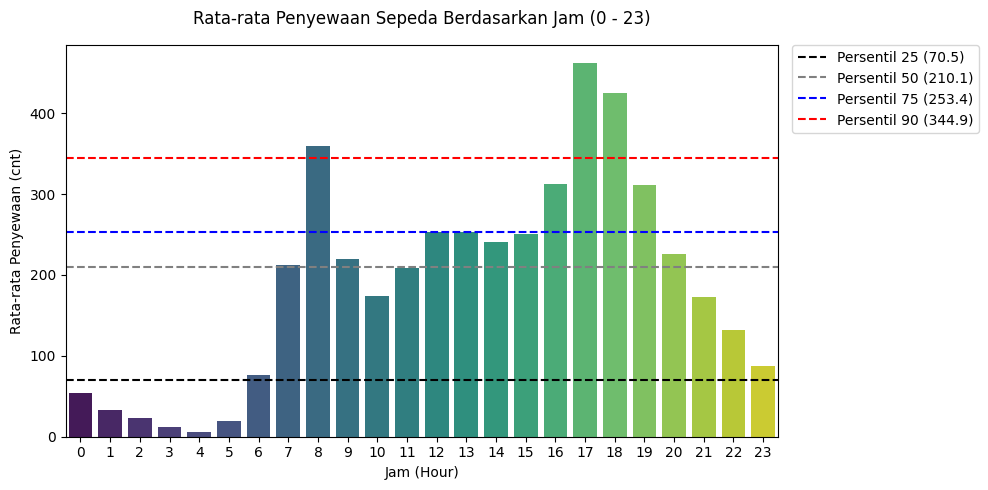

In [52]:
plt.figure(figsize=(10, 5))

max_cnt_hr = mean_cnt_hr['cnt'].max()
threshold_50 = max_cnt_hr * 0.50
threshold_75 = max_cnt_hr * 0.75
threshold_90 = max_cnt_hr * 0.90

ax = sns.barplot(
    data=mean_cnt_hr,
    x='hr',
    y='cnt',
    palette='viridis'
)

colors = {
    'q25': 'black',
    'q50': 'gray',
    'q75': 'blue',
    'q90': 'red'
}

for col_name, q_val in q_map_hr.items():
    threshold_val = mean_cnt_hr['cnt'].quantile(q_val)
    
    plt.axhline(
        y=threshold_val,
        color=colors[col_name],
        linestyle='--',
        linewidth=1.5,
        label=f'Persentil {int(q_val*100)} ({threshold_val:.1f})'
    )

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Jam (0 - 23)', fontsize=12, pad=15)
plt.xlabel('Jam (Hour)', fontsize=10)
plt.ylabel('Rata-rata Penyewaan (cnt)', fontsize=10)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()


**Insight:** Sepeda disewa dengan data sebagai berikut:  
* Rata-rata penyewaan di atas Kuantil 50 (Mediana/Top 50%): Jam 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19, dan 20 (12 jam operasional teramai).
* Rata-rata penyewaan di atas Kuantil 75 (Top 25% Teratas): Jam 8, 13, 16, 17, 18, dan 19.
* Rata-rata penyewaan di atas Kuantil 90 (Top 10% Teratas / Puncak Jam Sibuk): Jam 8, 17, dan 18 (puncak jam berangkat dan pulang kerja).
* Volume penyewaan terbesar sepanjang hari: Jam 17 (461.45 unit), disusul Jam 18 (425.51 unit) dan Jam 8 (359.01 unit).

### Binning

#### Korelasi rata-rata penyewaan sepeda terhadap suhu feels-like


Diubah dulu data normalisasinya menjadi data biasa.

In [53]:
hour_df['atemp_celcius'] = hour_df['atemp'] * 50

Berdasarkan gabungan standar [ASHRAE 55](https://www.ashrae.org/technical-resources/bookstore/standard-55-thermal-environmental-conditions-for-human-occupancy) dan [NOAA](https://www.noaa.gov/), suhu yang dirasakan di wilayah empat musim seperti Washington D.C. dapat dibagi menjadi 4 kategori:

| Rentang Suhu  | Kategori Label | Deskripsi Kenyamanan Pesepeda |
| :---: | :--- | :--- |
| **< 15°C** | **Sangat Dingin** (*Cold*) | Butuh pakaian tebal; kenyamanan berkurang untuk sepeda biasa. |
| **15°C – 20°C** | **Sejuk / Dingin** (*Cool*) | Suhu sejuk yang masih terbilang nyaman jika berpakaian pas. |
| **20,1°C – 27°C** | **Ideal / Nyaman** (*Comfortable*) | Zona paling ideal (*sweet spot*) untuk aktivitas fisik luar ruangan. |
| **> 27°C** | **Panas / Gerah** (*Warm / Hot*) | Mulai memicu keringat berlebih dan gerah (risiko dehidrasi). |

In [54]:
bins_atemp = [0, 15, 20, 27, 100]
labels_atemp = ['Sangat Dingin', 'Sejuk', 'Ideal', 'Panas']

In [55]:
hour_df['atemp_comfort'] = pd.cut(hour_df['atemp_celcius'], bins=bins_atemp, labels=labels_atemp, include_lowest=True)

In [56]:
mean_cnt_atemp = hour_df.groupby(by='atemp_comfort').agg({
    "cnt":"mean"
})

C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\2882878734.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_cnt_atemp = hour_df.groupby(by='atemp_comfort').agg({


In [57]:
mean_cnt_atemp

,cnt
atemp_comfort,
Sangat Dingin,84.289457
Sejuk,137.970353
Ideal,183.981531
Panas,263.697754


C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\1050367333.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


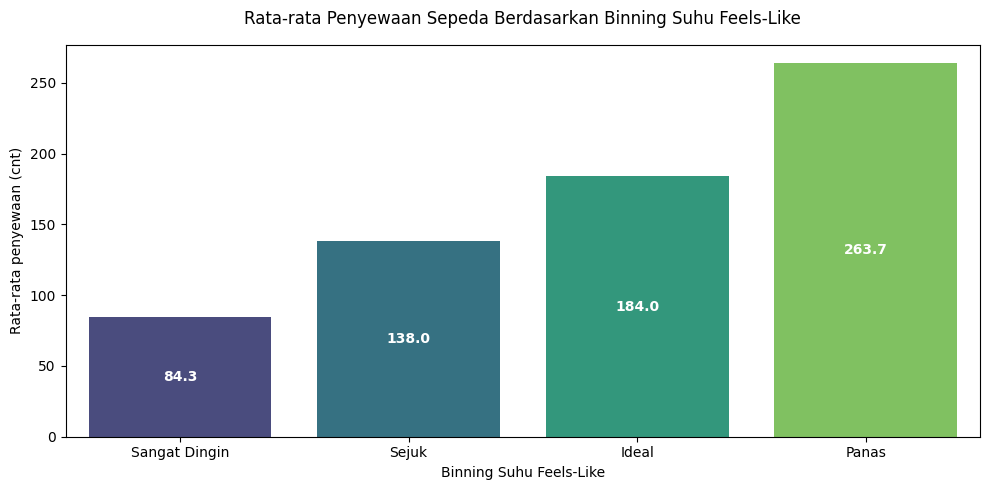

In [58]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=mean_cnt_atemp,
    x='atemp_comfort',
    y='cnt',
    palette='viridis'
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Binning Suhu Feels-Like', fontsize=12, pad=15)
plt.xlabel('Binning Suhu Feels-Like', fontsize=10)
plt.ylabel('Rata-rata penyewaan (cnt)', fontsize=10)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white',
                xytext=(0, 0), textcoords='offset points')

plt.tight_layout()
plt.show()


**Insight:** Rata rata penyewaan sepeda lebih tinggi saat Suhu Feels-Like bertipe Panas daripada Ideal, Sejuk, atau Sangat Dingin

#### Korelasi rata-rata penyewaan sepeda terhadap kelembapan udara

Diubah dulu data normalisasinya menjadi data biasa.

In [59]:
hour_df['hum_real'] = hour_df['hum'] * 100

Menurut Standar Kesehatan dan Lingkungan, biasanya kelembapan dibagi menjadi:
- Rendah (Kering): <40% 
- Sedang (Ideal/Normal) : 40-60%
- Tinggi (Sangat Lembap) : >60%

In [60]:
bins_hum = [0, 40, 60, 100]
labels_hum = ['Rendah', 'Sedang', 'Tinggi']

In [61]:
hour_df['hum_range'] = pd.cut(hour_df['hum_real'], bins=bins_hum, labels=labels_hum, include_lowest=True)

In [62]:
mean_cnt_hum = hour_df.groupby(by='hum_range').agg({
    "cnt":"mean"
})

C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\4007525480.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_cnt_hum = hour_df.groupby(by='hum_range').agg({


In [63]:
mean_cnt_hum

,cnt
hum_range,
Rendah,285.723276
Sedang,221.745683
Tinggi,145.180126


C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\1910497838.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


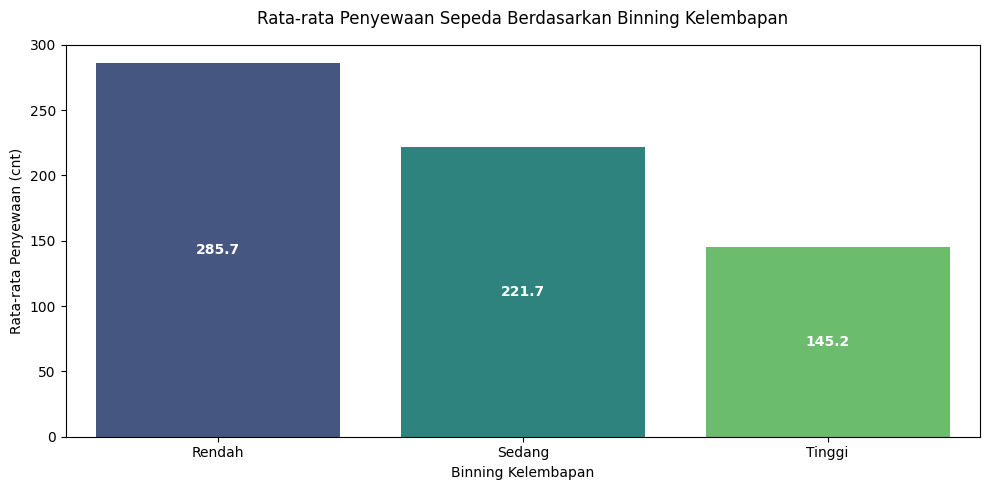

In [64]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=mean_cnt_hum,
    x='hum_range',
    y='cnt',
    palette='viridis'
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Binning Kelembapan', fontsize=12, pad=15)
plt.xlabel('Binning Kelembapan', fontsize=10)
plt.ylabel('Rata-rata Penyewaan (cnt)', fontsize=10)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white',
                xytext=(0, 0), textcoords='offset points')

plt.tight_layout()
plt.show()


**Insight:** Rata rata penyewaan sepeda lebih tinggi saat Kelembapannya Rendah daripada Sedang Atau Tinggi

#### Korelasi rata-rata penyewaan sepeda terhadap kecepatan angin

Diubah dulu data normalisasinya menjadi data biasa.

Karena di dataset tidak diketahui dinormalisasikan dari data satuan apa, dianggap kecepatannya kph (karena metrik cuaca dari dataset ini diambil dari FreeMeteo yang secara Default kph)

In [65]:
hour_df['windspeed_kph'] = hour_df['windspeed'] * 67

In [66]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,hum,windspeed,casual,registered,cnt,atemp_celcius,atemp_comfort,hum_real,hum_range,windspeed_kph
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.81,0.0,3,13,16,14.395,Sangat Dingin,81.0,Tinggi,0.0
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.80,0.0,8,32,40,13.635,Sangat Dingin,80.0,Tinggi,0.0
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.80,0.0,5,27,32,13.635,Sangat Dingin,80.0,Tinggi,0.0
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.75,0.0,3,10,13,14.395,Sangat Dingin,75.0,Tinggi,0.0
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.75,0.0,0,1,1,14.395,Sangat Dingin,75.0,Tinggi,0.0


Dilakukan Binning dengan menggunakan [Skala Beaufort](https://www.rmets.org/metmatters/beaufort-wind-scale)

| Skala Angin | Deskripsi | Kecepatan Angin (km/jam) | Spesifikasi / Dampak Visual |
| :---: | :--- | :---: | :--- |
| **0** | **Tenang** (*Calm*) | < 1 | Asap membumbung lurus ke atas. Permukaan laut tenang seperti cermin. |
| **1** | **Udara Tenang** (*Light Air*) | 1–5 | Arah angin terlihat dari hembusan asap, tetapi tidak pada penunjuk arah angin. Laut beriak. |
| **2** | **Hembusan Lembut** (*Light Breeze*) | 6–11 | Angin terasa di wajah; daun bergoyang pelan; penunjuk arah angin bergerak. Gelombang kecil terbentuk di laut. |
| **3** | **Hembusan Sedang** (*Gentle Breeze*) | 12–19 | Daun dan ranting kecil bergoyang terus-menerus; bendera ringan terbentang. Gelombang agak besar di laut. |
| **4** | **Angin Sedang** (*Moderate Breeze*) | 20–28 | Menerbangkan debu dan kertas lepas; dahan kecil bergerak. Gelombang kecil di laut, buih putih cukup sering muncul. |
| **5** | **Angin Agak Kencang** (*Fresh Breeze*) | 29–38 | Pohon-pohon kecil berdaun mulai bergoyang; gelombang berpuncak terbentuk di perairan darat. Gelombang sedang di laut, banyak buih putih. |
| **6** | **Angin Kencang** (*Strong Breeze*) | 38–49 | Dahan besar bergerak; siulan terdengar pada kawat telepon/telegram; payung sulit digunakan. Gelombang besar di laut, puncak buih meluas. |
| **7** | **Angin Kencang Sekali** (*Near Gale*) | 50–61 | Seluruh bagian pohon bergerak; terasa sulit saat berjalan melawan arah angin. Busa tertiup dalam bentuk garis-garis melintasi laut. |
| **8** | **Puting Beliung / Badai** (*Gale*) | 62–74 | Ranting-ranting patah dari pohon, umumnya menyulitkan pergerakan langkah kaki. Puncak gelombang mulai pecah menjadi percikan. |
| **9** | **Badai Kencang** (*Strong Gale*) | 75–88 | Kerusakan struktur ringan (cerobong asap dan genteng terlepas). Puncak gelombang roboh, percikan air mengganggu jarak pandang. |
| **10** | **Badai Hebat** (*Storm*) | 89–102 | Jarang terjadi di daratan; pohon-pohon tumbang; kerusakan struktur cukup parah. Permukaan laut sebagian besar berwarna putih. |
| **11** | **Badai Sangat Dahsyat** (*Violent Storm*) | 103–117 | Sangat jarang terjadi, disertai kerusakan meluas. Kapal berukuran sedang hilang dari pandangan di balik gelombang. Laut tertutup buih putih, jarak pandang sangat terganggu. |
| **12** | **Badai Topan / Hurikan** (*Hurricane*) | 118+ | Kehancuran total. Udara penuh dengan buih dan percikan air, jarak pandang sangat buruk. |

Dari Skala Beaufort diatas, akan dibuat binning seperti ini: 
- Light (0-5 kph),
- Breeze (6-49 kph),
- Gale (50-88 kph), dan
- Storm (89-188 kph)

In [67]:
bins_wind = [0, 5, 49, 88, 200]
labels_wind = ['Light', 'Breeze', 'Gale', 'Storm']

In [68]:
hour_df['windspeed_beaufort'] = pd.cut(hour_df['windspeed_kph'], bins=bins_wind, labels=labels_wind, include_lowest=True)

In [69]:
mean_cnt_windspeed = hour_df.groupby(by='windspeed_beaufort').agg({
    "cnt":"mean"
}).reset_index()

C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\3540609208.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_cnt_windspeed = hour_df.groupby(by='windspeed_beaufort').agg({


In [70]:
mean_cnt_windspeed

,windspeed_beaufort,cnt
0,Light,160.643578
1,Breeze,193.624449
2,Gale,140.875000
3,Storm,NaN


C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\3197578185.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


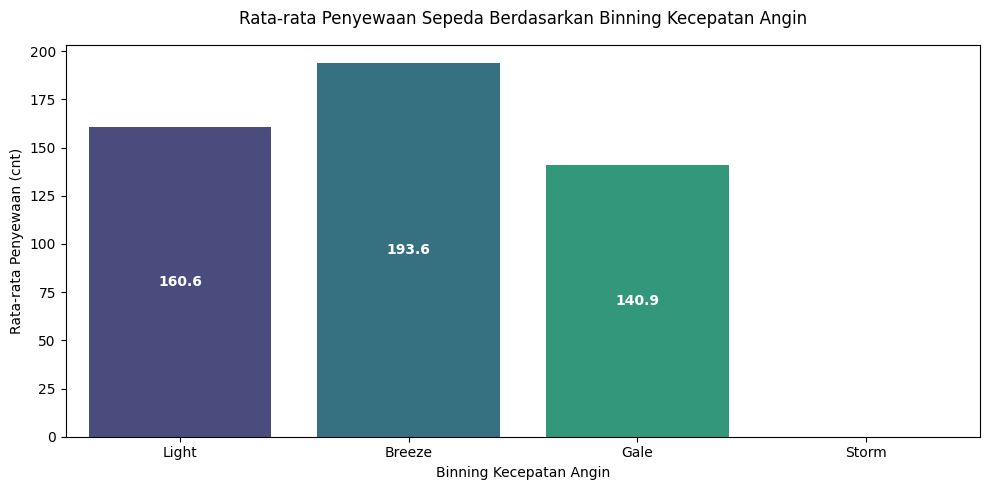

In [71]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=mean_cnt_windspeed,
    x='windspeed_beaufort',
    y='cnt',
    palette='viridis'
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Binning Kecepatan Angin', fontsize=12, pad=15)
plt.xlabel('Binning Kecepatan Angin', fontsize=10)
plt.ylabel('Rata-rata Penyewaan (cnt)', fontsize=10)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white',
                xytext=(0, 0), textcoords='offset points')

plt.tight_layout()
plt.show()


**Insight:** Rata rata penyewaan sepeda lebih tinggi saat Kecepatan anginnya Breeze (Berangin) dibandingkan dengan kecepatan angin lain

### Korelasi antara rata-rata pengguna casual dan registered berdasarkan hari kerja

In [72]:
mean_casualreg_workingday = day_df.groupby(by='workingday').agg({
    'casual':'mean',
    'registered':'mean'
}).reset_index()

In [73]:
mean_casualreg_workingday

,workingday,casual,registered
0,0,1371.134199,2959.034632
1,1,606.570000,3978.250000


C:\Users\ivana\AppData\Local\Temp\ipykernel_32016\1147924124.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Hari Libur/Weekend', 'Hari Kerja'])


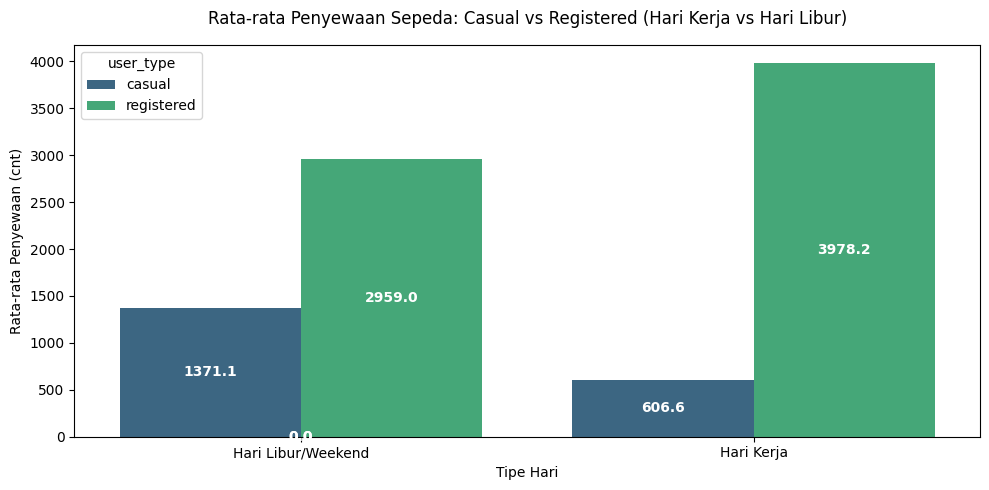

In [74]:
df_melted = mean_casualreg_workingday.melt(
    id_vars='workingday', 
    value_vars=['casual', 'registered'],
    var_name='user_type', 
    value_name='mean_rentals'
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df_melted,
    x='workingday',
    y='mean_rentals',
    hue='user_type',
    palette='viridis'
)

ax.set_xticklabels(['Hari Libur/Weekend', 'Hari Kerja'])

plt.title('Rata-rata Penyewaan Sepeda: Casual vs Registered (Hari Kerja vs Hari Libur)', fontsize=12, pad=15)
plt.xlabel('Tipe Hari', fontsize=10)
plt.ylabel('Rata-rata Penyewaan (cnt)', fontsize=10)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white',
                xytext=(0, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

**Insight:** Rata rata penyewa sepeda dengan tipe pengguna `casual` lebih besar pada Hari Libur/Weekend daripada Hari Kerja

Rata rata penyewa sepeda dengan tipe pengguna `registered` lebih besar pada Hari Kerja daripada Hari Libur

## Conclusion & Recommendation

### Conclusion

- **Conclusion pertanyaan 1:** Rata-rata penyewaan sepeda tahun 2012 pada jam Rush Hour (07.00 - 09.00 dan 16.00 - 18.00) lebih tinggi dibandingkan dengan jam lainnya, dengan total peningkatan rata-rata sebesar 327.22 atau sebesar 205.46%
- **Conclusion pertanyaan 2:** Rata-rata penyewaan sepeda tahun 2012 pada cuaca dengan kategori cerah (Clear, Few clouds, Partly cloudy, Partly cloudy) lebih banyak jika dibandingkan dengan cuaca dengan kategori yang lain, dengan cuaca kategori cerah memiliki rata-rata penyewaan sebesar 253.66, diikuti dengan cuaca kategori berawan (Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist) memiliki rata-rata penyewaan sebesar 212.99, cuaca kategori badai ringan (Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds) memiliki rata-rata penyewaan sebesar 142.37, dan cuaca kategori badai berat (Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog) memiliki rata-rata penyewaan sebesar 93.50
- **Conclusion pertanyaan 3:** Rata-rata penyewaan sepeda tahun 2011 sampai 2012 pada hari liburan lebih rendah dibandingkan dengan hari biasa, dengan penurunan penyewaan pada hari liburan sebesar 47.46 atau sekitar 18.17%

### Rekomendasi Action Item

*Pertanyaan 1*
- Meningkatkan ketersediaan sepeda yang bisa disewakan pada jam rush hour (07.00 - 09.00 dan 16.00 - 18.00) untuk mengantisipasi lonjakan permintaan sebesar lebih dari 205%.
-  Mengadakan Promosi Khusus di luar jam sibuk (rush hour) untuk menaikkan jumlah penyewa pada jam-jam sepi.

*Pertanyaaan 2*
- Menyiapkan penjadwalan pemeliharaan sepeda pada cuaca selain kategori cerah mengingat adanya penurunan rata-rata penyewaan pada cuaca lainnya

*Pertanyaan 3*
- Menyesuaikan jumlah sepeda yang bisa disewa pada hari liburan (holiday) agar dikurangi, karena volume permintaan terbukti lebih rendah sekitar 18.17%.
- Mengalihkan fokus pemasaran dan marketing di hari liburan ke arah rute-rute wisata, taman kota, atau area terbuka lainnya yang dapat dilewati oleh sepeda untuk menarik minat turis atau warga lokal yang ingin berlibur di kota tersebut untuk menaiki sepeda sewaan.



In [75]:
day_df['instant'].nunique() == len(day_df)

True

In [76]:
hour_df['instant'].nunique() == len(hour_df)

True

In [77]:
hour_df = hour_df.drop(columns=['atemp_celcius', 'atemp_comfort','hum_real','hum_range','windspeed_kph', 'windspeed_beaufort'])

In [78]:
day_df.to_parquet('day.parquet', index=False)
hour_df.to_parquet('hour.parquet', index=False)
